### Day10 Logistic Regression [Cont.]

### Perceptron Trick Logistic Regression

In [1]:
# import necessary libs.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class Perceptron:
    def __init__(self, epochs=50, learning_rate=1e-2):
        self.weights = None
        self.epochs = epochs
        self.eta = learning_rate

    def __step_fxn(self, z):
        return np.where(z >= 0, 1, 0)
    
    def fit(self, X_train, y_train):
        X_train = np.c_[ (np.ones( (X_train.shape[0], 1) )), X_train ]
    
        n_samples, n_features = X_train.shape
        y_train = y_train.reshape(-1, 1)

        self.weights = np.random.rand(n_features, 1)

        for epoch in range(self.epochs):
            y_hat = self.__step_fxn(X_train @ self.weights)
            self.weights = self.weights + self.eta * ( X_train.T @ (y_train - y_hat) )

    def predict(self, X_test):
        X_test = np.c_[ ( np.ones( (X_test.shape[0], 1) ) ), X_test ]
        return self.__step_fxn(X_test @ self.weights)

### Generating synthetic dataset

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from mlxtend.plotting import plot_decision_regions

In [4]:
X, y = make_classification(n_samples=100,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_repeated=0,
                          n_classes=2,
                          n_clusters_per_class=2,
                          class_sep=2,
                          weights=[0.5, 0.5],
                          random_state=42)

X.shape, y.shape

((100, 2), (100,))

In [5]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X = std_scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   random_state=42,
                                                   test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((70, 2), (30, 2), (70,), (30,))

In [15]:
perceptron_clf = Perceptron(epochs=250, learning_rate=1e-1)
perceptron_clf.fit(X_train, y_train)

<Axes: >

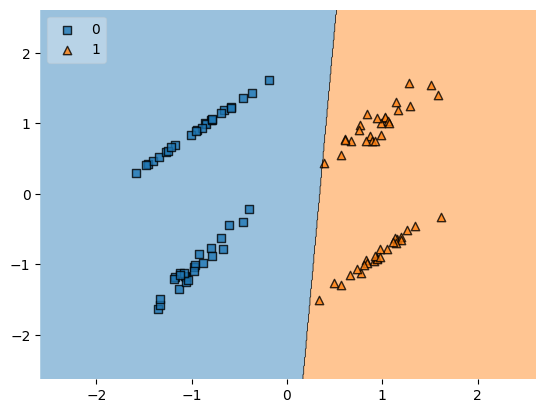

In [16]:
plot_decision_regions(X, y, clf=perceptron_clf, legend=2)